# Neural ODEs, part 3 — joint runs, non-rational laws, and a growing library

Part 2 ([`node_case1_library_sr.ipynb`](node_case1_library_sr.ipynb)) ended with three next steps. This
notebook implements all three for Case 1:

1. **Break the confounding.** Along one fed-batch run, biomass $X$ and substrate $S$ change together, so a
   falling μ can be blamed on either. Here every experiment has **three runs** with different inocula,
   initial substrate and feeds, fitted **jointly**: one Neural ODE and one set of kinetic parameters for all
   three runs.
2. **Reach non-rational laws.** The symbolic-regression dictionary gains an exponential term
   $S\,e^{-S/K}$ with a fitted $K$. It expresses Tessier and Aiba exactly, which part 2 could only approximate.
3. **Close the loop.** A law found by symbolic regression is *accepted* when the evidence is strong and
   the law fits within the noise. It is then added to the library, and a later experiment is identified with
   the enlarged library alone.

When the library fails to explain an experiment (a χ² test against the noise level), symbolic regression
**escalates**: instead of trusting the learned rates to shortlist candidate laws, it screens every valid law
against the data.

The Neural ODE, the refinement and the BIC selection are those of parts 1–2 (see `node/README.md`).

**Requirements:** kintrace's `requirements.txt` plus `torchdiffeq` and `sympy`.
Run from `kintrace/node/notebooks/`. The full notebook takes about 35 min on a CPU.

In [1]:
import os, sys, copy, time, itertools, warnings, contextlib
import numpy as np
import pandas as pd
import sympy as sp
import torch
import torch.nn as nn
from torchdiffeq import odeint
from scipy.integrate import odeint as scipy_odeint, ODEintWarning
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))   # kintrace repository root
assert os.path.isdir(os.path.join(ROOT, "kinetic_models")), "run this notebook from kintrace/node/notebooks"
sys.path.insert(0, ROOT)

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)            # the networks are tiny: extra threads only add overhead
warnings.filterwarnings("ignore", category=ODEintWarning)     # odeint warns on stiff candidates during fitting


@contextlib.contextmanager
def fortran_quiet():
    """LSODA (inside odeint) prints its warnings from Fortran, straight to the process's stdout, so
    Python cannot filter them. Point file descriptor 1 at /dev/null while it runs."""
    saved, null = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 1)
    try:
        yield
    finally:
        os.dup2(saved, 1)
        os.close(null)
        os.close(saved)


C_NODE, C_MECH, C_SR, C_DATA, C_TRUE = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#898781"
RUN_COLORS = {"a": "#2a78d6", "b": "#eb6834", "c": "#1baf7a"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 1.8,
})

## Shared building blocks

As in parts 1–2, with one change: `train_node` now takes measurements shaped (time, runs, channels), so
one Neural ODE can be trained on several runs at once.

* `refine`: bounded least squares in normalised coordinates z ∈ [1, 2], finite-difference step 1e-3.
* `identify`: refines every candidate from each starting point, keeps the best fit, and ranks by
  BIC = χ² + k·ln n. The initial states are refined together with the parameters. *Changed:* they may now
  move up to 3 noise standard deviations from their estimate. Parts 1–2 used ±50 % around the Neural ODE's
  estimate, which can exclude the true value when the Neural ODE is off.
* `initial_state`: the estimate itself, the intercept of a straight line through the first three samples
  of each channel. A fast-falling substrate makes the median of the first samples (part 2) a poor start.

In [2]:
def mlp(n_in, n_out, hidden=16):
    return nn.Sequential(nn.Linear(n_in, hidden), nn.Tanh(),
                         nn.Linear(hidden, hidden), nn.Tanh(),
                         nn.Linear(hidden, n_out))


def train_node(model, t_obs, Y_obs, n_iter=300, lr=1e-2):
    """Adam on the range-scaled MSE. Y_obs has shape (time, runs, channels); NaNs are ignored.
    Keeps the best full-horizon state and returns its loss."""
    t, Y = torch.tensor(t_obs), torch.tensor(Y_obs)
    mask, Y = torch.isfinite(Y), torch.nan_to_num(Y)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss, best_state = np.inf, None
    for it in range(n_iter):
        k = max(4, int(min(1.0, 0.25 + it / (0.5 * n_iter)) * len(t)))     # growing horizon
        opt.zero_grad()
        r = (model.simulate(t[:k])[..., :Y.shape[-1]] - Y[:k]) / model.loss_scale
        loss = (r[mask[:k]] ** 2).mean()
        loss.backward()
        opt.step()
        if k == len(t) and loss.item() < best_loss:
            best_loss, best_state = loss.item(), copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return best_loss


def refine(simulate, theta0, lb, ub, t_obs, Y_obs, sigma, max_nfev=300):
    """Bounded least squares in normalised coordinates z in [1, 2]. Returns (theta, chi2, n_evals)."""
    mask = np.isfinite(Y_obs)
    to_theta = lambda z: lb + (z - 1) * (ub - lb)

    def residuals(z):
        Y = simulate(to_theta(z), t_obs)
        return np.full(mask.sum(), 1e3) if Y is None else ((Y - Y_obs) / sigma)[mask]

    z0 = 1 + (np.clip(theta0, lb, ub) - lb) / (ub - lb)
    r = least_squares(residuals, z0, bounds=(1, 2), diff_step=1e-3, max_nfev=max_nfev)
    return to_theta(r.x), float(np.sum(r.fun ** 2)), r.nfev


def identify(candidates, starts, simulate, bounds, x0, t_obs, Y_obs, sigma):
    """Refine every candidate from each starting point in starts(mid) (a dict name -> theta0), keep the best
    fit, and rank the candidates by BIC."""
    x0 = np.asarray(x0, dtype=float)
    x0_lb, x0_ub = np.maximum(x0 - 3 * sigma, 0), x0 + 3 * sigma        # within 3 noise SDs of the estimate
    rows = []
    for mid in candidates:
        (lb, ub), row, best = bounds(mid), dict(mechanism=mid, nfev=0), None
        for name, theta0 in starts(mid).items():
            n = len(theta0)
            theta, chi2, nfev = refine(lambda th, t: simulate(mid, th[:n], t, th[n:]), np.r_[theta0, x0],
                                       np.r_[lb, x0_lb], np.r_[ub, x0_ub], t_obs, Y_obs, sigma)
            row[f"chi2 from {name}"], row["nfev"] = chi2, row["nfev"] + nfev
            if best is None or chi2 < best[1]:
                best = (theta, chi2)
        rows.append(dict(row, k=n, chi2=best[1], theta=best[0][:n], x0=best[0][n:]))
    return add_bic(pd.DataFrame(rows).set_index("mechanism"), np.isfinite(Y_obs).sum())


def initial_state(Y):
    """Initial state of every channel: intercept at t = 0 of a straight line through the first three samples,
    floored at 2 % of the channel's maximum (a culture started at zero never grows). Y: (time, ..., channels)."""
    A = np.c_[np.ones(3), t_obs[:3]]
    y0 = np.tensordot(np.linalg.pinv(A), Y[:3], axes=1)[0]
    return np.maximum(y0, 0.02 * Y.max(0))


def add_bic(df, n_data):
    """BIC = chi2 + k ln n, and BIC weights exp(-dBIC/2) normalised over the candidates in df."""
    df = df.copy()
    df["BIC"] = df.chi2 + df.k * np.log(n_data)
    w = np.exp(-(df.BIC - df.BIC.min()) / 2)
    df["weight"] = w / w.sum()
    return df

## The 11-mechanism library (as in part 2)

Monod, Contois, Haldane and biomass inhibition, each with and without cell death $k_d$, plus Tessier, Moser
and Aiba. Each library entry holds its rate law, parameter names, the centre of its sampling ranges (the
"naive" starting point) and its fitting bounds (0.1×–5× the sampling ranges). Later, laws found by symbolic
regression become entries of the same kind.

In [3]:
from datagen.param_ranges_simple import PARAM_RANGES_SIMPLE
from datagen.feed_profiles_simple import make_feed_fn
from datagen.noise import add_gaussian_noise

RATE_LAWS = {   # name: (mu(X, S, p), kinetic parameter names)
    "monod":       (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S), ["mumax", "Ks"]),
    "contois":     (lambda X, S, p: p["mumax"] * S / (p["Kc"] * X + S), ["mumax", "Kc"]),
    "haldane":     (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S + S ** 2 / p["KI"]), ["mumax", "Ks", "KI"]),
    "biomass_inh": (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S) * np.maximum(1 - X / p["Xmax"], 0),
                    ["mumax", "Ks", "Xmax"]),
    "tessier":     (lambda X, S, p: p["mumax"] * (1 - np.exp(-S / p["Ks"])), ["mumax", "Ks"]),
    "moser":       (lambda X, S, p: p["mumax"] * S ** p["n"] / (p["Ks"] + S ** p["n"]), ["mumax", "Ks", "n"]),
    "aiba":        (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S) * np.exp(-S / p["KI"]), ["mumax", "Ks", "KI"]),
}
RANGES = {**PARAM_RANGES_SIMPLE[3], **PARAM_RANGES_SIMPLE[2], **PARAM_RANGES_SIMPLE[4],
          "kd": (0.005, 0.1), "n": (1.0, 3.0)}
RANGES_BY_LAW = {"moser": {"Ks": (0.1, 25.0)}, "aiba": {"KI": (5.0, 50.0)}}


def library_entry(law, death):
    mu_fn, kin = RATE_LAWS[law]
    names = kin + (["kd"] if death else []) + ["Yxs"]
    r = {**RANGES, **RANGES_BY_LAW.get(law, {})}
    lo, hi = np.array([r[n][0] for n in names]), np.array([r[n][1] for n in names])
    return dict(mu=mu_fn, names=names, death=death, centre=0.5 * (lo + hi), bounds=(0.1 * lo, 5 * hi))


LIBRARY = {}
for law in ["monod", "contois", "haldane", "biomass_inh"]:
    LIBRARY[law], LIBRARY[law + "+kd"] = library_entry(law, False), library_entry(law, True)
for law in ["tessier", "moser", "aiba"]:
    LIBRARY[law] = library_entry(law, False)


def rhs(y, t, mu_fn, p, feed, Sin):
    X, S, V = max(y[0], 0.0), max(y[1], 0.0), y[2]
    F = feed(t)
    D = F / V
    mu = mu_fn(X, S, p)
    return [(mu - p.get("kd", 0.0) - D) * X, -mu * X / p["Yxs"] + D * (Sin - S), F]


def simulate_runs(mu_fn, p, t, x0, runs):
    """Integrate every run with its own feed and initial state x0 = [X0, S0, X0, S0, ...].
    Returns [X, S] of all runs side by side, shape (T, 2 * runs), or None if a run fails or blows up."""
    out = []
    for i, run in enumerate(runs):
        try:
            with fortran_quiet():
                y = scipy_odeint(rhs, [*x0[2 * i:2 * i + 2], run["V0"]], t, args=(mu_fn, p, run["feed"], run["Sin"]),
                                 rtol=1e-6, atol=1e-8, mxstep=5000)
        except Exception:
            return None
        if not np.all(np.isfinite(y)) or np.abs(y).max() > 1e6:
            return None
        out.append(y[:, :2])
    return np.hstack(out)


def simulate(entry, theta, t, x0, runs):
    return simulate_runs(entry["mu"], dict(zip(entry["names"], theta)), t, x0, runs)

---
## Step 1 — break the confounding with jointly fitted runs

### The experiment design

Every experiment now has three 24 h fed-batch runs, each sampled 49 times with 3 % noise:

| run | inoculum $X_0$ | initial substrate $S_0$ | feed (four 6 h segments, L/h) | what it shows |
|---|---|---|---|---|
| a | 1 g/L | 30 g/L | 0, 0.02, 0.05, 0.08 | the part 1–2 run: batch phase, then rising feed |
| b | 4 g/L | 5 g/L | 0.03, 0.03, 0.06, 0.06 | high biomass at low substrate from the start |
| c | 0.5 g/L | 60 g/L | 0, 0, 0.03, 0.06 | low biomass at high substrate |

Runs b and c put high biomass with low substrate, and low biomass with high substrate, into the same
experiment. A law in which μ falls with $X$ (Contois, biomass inhibition) and one in which it falls with $S$
(Haldane, Aiba) now predict clearly different behaviour. Run a uses the same data as part 2 (the same noise
seeds), so its single-run results can be compared directly.

The same 11 library mechanisms plus the hidden law of part 2 generate 12 experiments:

$$\mu_{hidden} = 0.6\,\frac{S}{1 + S + S^2/20}\left(1 - \frac{X}{30}\right).$$

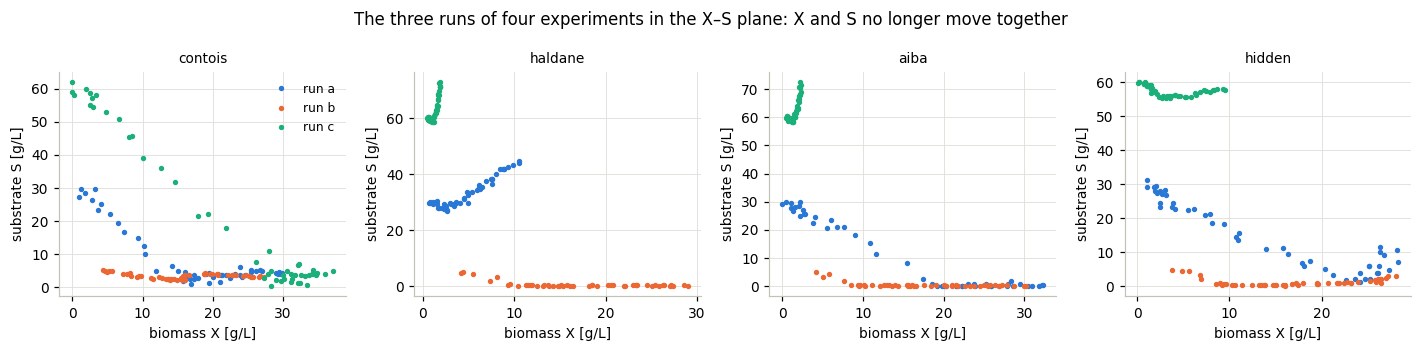

In [4]:
DESIGN = {
    "a": dict(X0=1.0, S0=30.0, V0=1.5, Sin=120.0, t_total=24.0, feed_rates=[0.0, 0.02, 0.05, 0.08]),
    "b": dict(X0=4.0, S0=5.0, V0=1.5, Sin=120.0, t_total=24.0, feed_rates=[0.03, 0.03, 0.06, 0.06]),
    "c": dict(X0=0.5, S0=60.0, V0=1.5, Sin=120.0, t_total=24.0, feed_rates=[0.0, 0.0, 0.03, 0.06]),
}
for d in DESIGN.values():
    d["feed"] = make_feed_fn(d)                             # kintrace piecewise-constant feed F(t) [L/h]
N_OBS, NOISE = 49, 0.03
t_obs = np.linspace(0, 24.0, N_OBS)
TRUE = {   # parameters in each entry's order: kinetic, (kd), Yxs
    "monod": [0.5, 2.0, 0.5],             "monod+kd": [0.5, 2.0, 0.04, 0.5],
    "contois": [0.5, 1.0, 0.5],           "contois+kd": [0.5, 1.0, 0.04, 0.5],
    "haldane": [0.6, 1.0, 8.0, 0.5],      "haldane+kd": [0.6, 1.0, 8.0, 0.04, 0.5],
    "biomass_inh": [0.5, 1.0, 20.0, 0.5], "biomass_inh+kd": [0.5, 1.0, 20.0, 0.04, 0.5],
    "tessier": [0.5, 3.0, 0.5],           "moser": [0.5, 16.0, 2.0, 0.5],        "aiba": [0.6, 1.0, 30.0, 0.5],
}
HIDDEN_P = dict(mumax=0.6, Ks=1.0, KI=20.0, Xmax=30.0, Yxs=0.5)
hidden_mu = lambda X, S, p: RATE_LAWS["haldane"][0](X, S, p) * np.maximum(1 - X / p["Xmax"], 0)


def make_experiment(mu_fn, p, design, seeds):
    """Simulate and add noise to every run of a design; returns the list of runs."""
    runs = []
    for (key, d), seed in zip(design.items(), seeds):
        truth = simulate_runs(mu_fn, p, t_obs, [d["X0"], d["S0"]], [d])
        Y = add_gaussian_noise(truth, NOISE, clip_zero=True, seed=seed)
        runs.append(dict(d, key=key, truth=truth, Y=Y, sigma=NOISE * (Y.max(0) - Y.min(0))))
    return runs


experiments = {}
for i, (name, theta) in enumerate(list(TRUE.items()) + [("hidden", None)]):
    mu_fn, p = (hidden_mu, HIDDEN_P) if name == "hidden" else (LIBRARY[name]["mu"], dict(zip(LIBRARY[name]["names"], theta)))
    experiments[name] = dict(mu_fn=mu_fn, p=p, runs=make_experiment(mu_fn, p, DESIGN, seeds=[i, 100 + i, 200 + i]))

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, name in zip(axes, ["contois", "haldane", "aiba", "hidden"]):
    for run in experiments[name]["runs"]:
        ax.plot(run["Y"][:, 0], run["Y"][:, 1], "o", ms=2.5, color=RUN_COLORS[run["key"]], label=f"run {run['key']}")
    ax.set(title=name, xlabel="biomass X [g/L]", ylabel="substrate S [g/L]")
axes[0].legend()
fig.suptitle("The three runs of four experiments in the X–S plane: X and S no longer move together")
fig.tight_layout()

### One Neural ODE for three runs

The model of part 2 is applied to all three runs at once. The rate network $\mu(X, S)$, the yield $Y_{XS}$
and the death rate $k_d$ are shared; only the initial states are per run. The runs are integrated together
as one batched state of shape (runs, 3), so training costs barely more than for one run. The network's
inputs are scaled by the largest values over all runs, so the same $(X, S)$ means the same input in every run.

Two settings differ from part 2, both because of run b, whose substrate collapses from 5 to below 1 g/L
within the first hour:
* the substrate factor uses $K = 0.1 \times$ the *median* over runs of each run's largest substrate value
  (≈ 3 g/L). The largest value over all runs (run c, ≈ 70 g/L) would give $K ≈ 7$ g/L, far above run b's
  whole substrate range, and the network could not express its fast low-substrate kinetics;
* the RK4 step is 0.25 h instead of 0.5 h, because the smaller $K$ makes the substrate balance stiffer.

In [5]:
class HybridMulti(nn.Module):
    """dX = (mu - kd - D) X,  dS = -mu X / Yxs + D (Sin - S),  dV = F  for several runs at once,
    with mu(X, S) = softplus(NN) * S / (S + K) shared by all runs."""
    step = 0.25                                                  # RK4 step [h]

    def __init__(self, runs):
        super().__init__()
        Y = np.stack([r["Y"] for r in runs], 1)                  # (T, runs, 2)
        self.runs = runs
        self.scale = torch.tensor(Y.max((0, 1)))                 # input scale, shared by all runs
        self.loss_scale = torch.tensor(Y.max(0) - Y.min(0))      # per run and channel: noise is 3 % of range
        self.y_first = torch.tensor(initial_state(Y))           # (runs, 2)
        self.K = 0.1 * float(np.median(Y[..., 1].max(0)))        # 10 % of a typical run's substrate range
        self.dy0 = nn.Parameter(torch.zeros_like(self.y_first))  # per-run correction of the initial state
        self.V0 = torch.tensor([r["V0"] for r in runs])
        self.Sin = torch.tensor([r["Sin"] for r in runs])
        self.net = mlp(2, 1)
        self.log_Yxs = nn.Parameter(torch.tensor(np.log(0.5)))
        self.log_kd = nn.Parameter(torch.tensor(np.log(0.01)))

    def mu(self, X, S):
        S = S.clamp(min=0)
        g = nn.functional.softplus(self.net(torch.stack([X, S], -1) / self.scale)).squeeze(-1)
        return g * S / (S + self.K)

    def forward(self, t, y):
        X, S, V = y.unbind(-1)                                   # each of shape (runs,)
        F = torch.tensor([r["feed"](float(t)) for r in self.runs])
        D = F / V
        mu = self.mu(X, S)
        return torch.stack([(mu - torch.exp(self.log_kd) - D) * X,
                            -mu * X / torch.exp(self.log_Yxs) + D * (self.Sin - S), F], -1)

    def simulate(self, t):
        x0 = (self.y_first + 0.05 * self.scale * self.dy0).clamp(min=0)
        y0 = torch.cat([x0, self.V0[:, None]], -1)
        return odeint(self, y0, torch.as_tensor(t), method="rk4", options=dict(step_size=self.step))


T_DENSE = np.linspace(0, 24.0, 97)


def fit_node(runs):
    """Train the shared Neural ODE; return the learned rates and states along all runs (concatenated)."""
    torch.manual_seed(0)
    model = HybridMulti(runs)
    loss = train_node(model, t_obs, np.stack([r["Y"] for r in runs], 1))
    with torch.no_grad():
        yd = model.simulate(T_DENSE)                             # (T, runs, 3)
        mu = model.mu(yd[..., 0], yd[..., 1])
    yd, mu = yd.numpy(), mu.numpy()
    return dict(loss=loss, X=yd[..., 0].T.ravel(), S=np.clip(yd[..., 1], 0, None).T.ravel(), mu=mu.T.ravel(),
                x0=yd[0, :, :2].ravel(), Yxs=torch.exp(model.log_Yxs).item(), kd=torch.exp(model.log_kd).item())


for name, e in experiments.items():
    t0 = time.time()
    e["node"] = fit_node(e["runs"])
    print(f"{name:15s} loss {e['node']['loss']:.1e}  Yxs {e['node']['Yxs']:.3f} (true {e['p']['Yxs']})  "
          f"kd {e['node']['kd']:.3f} (true {e['p'].get('kd', 0.0)})  [{time.time() - t0:.0f} s]")

monod           loss 8.3e-04  Yxs 0.530 (true 0.5)  kd 0.006 (true 0.0)  [43 s]


monod+kd        loss 9.0e-04  Yxs 0.473 (true 0.5)  kd 0.034 (true 0.04)  [46 s]


contois         loss 2.4e-03  Yxs 0.536 (true 0.5)  kd 0.010 (true 0.0)  [49 s]


contois+kd      loss 3.1e-03  Yxs 0.425 (true 0.5)  kd 0.024 (true 0.04)  [42 s]


haldane         loss 5.7e-03  Yxs 0.504 (true 0.5)  kd 0.009 (true 0.0)  [37 s]


...

biomass_inh+kd  loss 1.1e-03  Yxs 0.465 (true 0.5)  kd 0.032 (true 0.04)  [40 s]


tessier         loss 1.0e-03  Yxs 0.518 (true 0.5)  kd 0.004 (true 0.0)  [41 s]


moser           loss 2.3e-03  Yxs 0.522 (true 0.5)  kd 0.006 (true 0.0)  [52 s]


aiba            loss 6.0e-03  Yxs 0.461 (true 0.5)  kd 0.011 (true 0.0)  [44 s]


hidden          loss 4.7e-03  Yxs 0.515 (true 0.5)  kd 0.007 (true 0.0)  [46 s]


### Library selection: one run against three

For each experiment, the 11 library mechanisms are refined and ranked twice: on **run a alone** (the
part 2 situation) and on **all three runs jointly**, where the kinetic parameters are shared and the initial
states are per run. Both use the same two starting points: the rate law matched to the jointly learned μ,
and the centre of the sampling ranges.

**Does the best mechanism fit within the noise?** If a model is right, χ² is about $n - p$, with a spread
of about $\sqrt{2n}$. With $n = 294$ measured values per experiment, a best χ² above
$n + 3\sqrt{2n} \approx 367$ means no library mechanism explains the experiment.

In [6]:
def match(entry, dense):
    """Initial guess for a library entry: fit its rate law to the learned mu; Yxs and kd from the Neural ODE."""
    lb, ub = entry["bounds"]
    kin = [n for n in entry["names"] if n not in ("kd", "Yxs")]
    k = len(kin)

    def residuals(theta_kin):
        return entry["mu"](dense["X"], dense["S"], dict(zip(kin, theta_kin))) - dense["mu"]

    r = least_squares(residuals, entry["centre"][:k], bounds=(lb[:k], ub[:k]), x_scale=(ub - lb)[:k])
    return np.clip(np.r_[r.x, [dense["kd"]] if entry["death"] else [], dense["Yxs"]], lb, ub)


def select(library, runs, dense, starts=None):
    """Refine and rank every entry of `library` on the given runs (jointly)."""
    starts = starts or (lambda m: {"NODE": match(library[m], dense), "centre": library[m]["centre"]})
    return identify(list(library), starts=starts,
                    simulate=lambda m, th, t, x0: simulate(library[m], th, t, x0, runs),
                    bounds=lambda m: library[m]["bounds"], x0=initial_state(np.hstack([r["Y"] for r in runs])), t_obs=t_obs,
                    Y_obs=np.hstack([r["Y"] for r in runs]), sigma=np.hstack([r["sigma"] for r in runs]))


for name, e in experiments.items():
    t0 = time.time()
    e["single"] = select(LIBRARY, e["runs"][:1], e["node"])
    e["joint"] = select(LIBRARY, e["runs"], e["node"])
    print(f"{name:15s} single and joint selection in {time.time() - t0:.0f} s")


N_DATA = 2 * N_OBS * len(DESIGN)                 # 294 measured values per experiment
CHI2_OK = N_DATA + 3 * np.sqrt(2 * N_DATA)       # upper edge of the noise band for chi2 (about 367)


def shortlist(df):
    return ", ".join(f"{m} ({w:.2f})" for m, w in df.weight.sort_values(ascending=False).items() if w > 0.1)


rows = []
for name, e in experiments.items():
    s, j = e["single"], e["joint"]
    rows.append({"experiment": name,
                 "run a: selected": f"{s.weight.idxmax()} ({s.weight.max():.2f})",
                 "3 runs: selected": f"{j.weight.idxmax()} ({j.weight.max():.2f})",
                 "3 runs: shortlist (w > 0.1)": shortlist(j),
                 "3 runs: best χ² (n = 294)": round(j.chi2.min(), 1),
                 "fits within noise": "yes" if j.chi2.min() <= CHI2_OK else "NO"})
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows).set_index("experiment")

monod           single and joint selection in 35 s


monod+kd        single and joint selection in 35 s


contois         single and joint selection in 20 s


contois+kd      single and joint selection in 22 s


haldane         single and joint selection in 27 s


...

tessier         single and joint selection in 38 s


moser           single and joint selection in 28 s


aiba            single and joint selection in 44 s


hidden          single and joint selection in 35 s


,run a: selected,3 runs: selected,3 runs: shortlist (w > 0.1),3 runs: best χ² (n = 294),fits within noise
experiment,,,,,
monod,contois (0.40),monod (0.86),monod (0.86),244.2,yes
monod+kd,contois+kd (0.47),monod+kd (0.97),monod+kd (0.97),264.8,yes
contois,contois (0.81),contois (0.94),contois (0.94),278.9,yes
contois+kd,contois+kd (0.80),contois+kd (1.00),contois+kd (1.00),310.1,yes
haldane,contois (0.87),haldane (0.92),haldane (0.92),267.9,yes
haldane+kd,aiba (0.82),haldane+kd (1.00),haldane+kd (1.00),243.9,yes
biomass_inh,biomass_inh (0.90),biomass_inh (0.95),biomass_inh (0.95),226.4,yes
biomass_inh+kd,biomass_inh+kd (1.00),biomass_inh+kd (1.00),biomass_inh+kd (1.00),255.9,yes
tessier,tessier (0.35),tessier (0.54),"tessier (0.54), aiba (0.26), monod (0.15)",302.0,yes


BIC weights with three runs (rows: true mechanism; columns: candidates). A dark diagonal means the true
mechanism was selected.

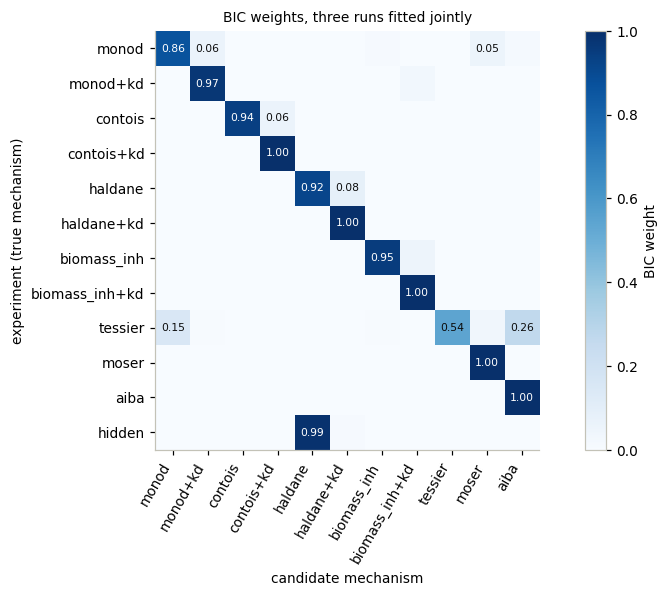

In [7]:
W = pd.DataFrame({name: e["joint"].weight for name, e in experiments.items()}).T[list(LIBRARY)]
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(W.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(W.shape[1]))
ax.set_xticklabels(W.columns, rotation=60, ha="right")
ax.set_yticks(range(W.shape[0]))
ax.set_yticklabels(W.index)
ax.grid(False)
for i, j in zip(*np.nonzero(W.values >= 0.05)):
    ax.text(j, i, f"{W.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
            color="white" if W.values[i, j] > 0.6 else "#0b0b0b")
ax.set(xlabel="candidate mechanism", ylabel="experiment (true mechanism)", title="BIC weights, three runs fitted jointly")
fig.colorbar(im, fraction=0.03, label="BIC weight")
fig.tight_layout()

---
## Step 2 — symbolic regression that reaches non-rational laws

Part 2's symbolic regression wrote a rate law as $\mu S = \sum_k c_k\,\theta_k$ over rational terms. One
extra term with a fitted constant $K$,

$$\theta = S\,e^{-S/K},$$

makes two non-rational laws exactly expressible:

| law | rate | written as terms |
|---|---|---|
| Tessier | $\mu_{max}(1 - e^{-S/K_S})$ | $\mu S = \mu_{max}\,S - \mu_{max}\,S e^{-S/K}$: terms $S$, $Se^{-S/K}$ |
| Aiba | $\mu_{max}\frac{S}{K_S + S}e^{-S/K_I}$ | $\mu S = \mu_{max}\,S e^{-S/K} - K_S\,\mu$: terms $Se^{-S/K}$, $\mu$ |

Moser ($S^n$) remains out of reach. Each law is fitted to the learned μ directly, with the same rules as part 2:
a numerator is required, denominator terms are positive, the rate is non-negative along the runs, and the
rate vanishes when the substrate runs out. The last rule is now checked directly, as
$\mu(X, S \to 0) \le 5\,\%$ of the largest learned rate. Part 2's check (a positive denominator at $S = 0$)
would reject Tessier, whose denominator is just $S$.

With three runs, the learned μ covers the whole X–S region the runs visit, so symbolic regression sees the
deconfounded rates too.

In [8]:
def exp_(x):
    return sp.exp(x) if isinstance(x, sp.Basic) else np.exp(x)


SR_TERMS = {   # theta_k(v, q) in  mu*S = sum_k c_k theta_k; terms named "mu..." are multiplied by mu
    "S": lambda v, q: v["S"],
    "S*X": lambda v, q: v["S"] * v["X"],
    "S^2": lambda v, q: v["S"] ** 2,
    "S*exp(-S/K)": lambda v, q: v["S"] * exp_(-v["S"] / q["K"]),
    "mu": lambda v, q: v["S"] ** 0,
    "mu*X": lambda v, q: v["X"],
    "mu*S^2": lambda v, q: v["S"] ** 2,
    "mu*S*X": lambda v, q: v["S"] * v["X"],
}


def sr_parts(v, law):
    """Numerator and denominator of  mu = N / D  for a law {terms, coef, q}."""
    q = law["q"]
    num = sum(c * SR_TERMS[k](v, q) for k, c in zip(law["terms"], law["coef"]) if not k.startswith("mu")) + 0 * v["S"]
    den = v["S"] - sum(c * SR_TERMS[k](v, q) for k, c in zip(law["terms"], law["coef"]) if k.startswith("mu"))
    return num, den


def sr_mu(v, law):
    num, den = sr_parts(v, law)
    return np.where(den > 1e-12, num / np.maximum(den, 1e-12), 0.0)    # 0 where the law is undefined


def fit_law(v, mu, terms):
    """Fit the law given by `terms` to the learned rate mu: free numerator coefficients, non-negative
    denominator coefficients and, for the exponential term, a fitted K. Returns (law, relative error)."""
    plain = [k for k in terms if not k.startswith("mu")]
    dens = [k for k in terms if k.startswith("mu")]
    has_K = any("K" in k for k in terms)
    n_a, n_b = len(plain), len(dens)

    def law_of(p):
        q = {"K": np.exp(p[-1])} if has_K else {}
        return dict(terms=list(terms), q=q,
                    coef=[p[plain.index(k)] if k in plain else -p[n_a + dens.index(k)] for k in terms])

    best = None
    for K0 in (np.geomspace(0.03, 3, 5) * v["S"].max() if has_K else [None]):
        q = {"K": K0} if has_K else {}
        Q = np.column_stack([SR_TERMS[k](v, q) * np.ones_like(mu) for k in dens] + [np.zeros_like(mu)])[:, :n_b]
        b0 = 0.1 * v["S"].mean() / np.maximum(Q.mean(0), 1e-12)             # each denominator term ~10 % of S
        N = np.column_stack([SR_TERMS[k](v, q) * np.ones_like(mu) for k in plain])
        a0 = np.linalg.lstsq(N, mu * (v["S"] + Q @ b0), rcond=None)[0]
        p0 = np.r_[a0, b0, [np.log(K0)] if has_K else []]
        lb = np.r_[np.full(n_a, -np.inf), np.zeros(n_b), [np.log(1e-3 * v["S"].max())] if has_K else []]
        ub = np.r_[np.full(n_a + n_b, np.inf), [np.log(1e3 * v["S"].max())] if has_K else []]
        fit = least_squares(lambda p: sr_mu(v, law_of(p)) - mu, p0, bounds=(lb, ub), x_scale="jac")
        if best is None or fit.cost < best.cost:
            best = fit
    law = law_of(best.x)
    return law, np.linalg.norm(sr_mu(v, law) - mu) / np.linalg.norm(mu)


def sr_candidates(v, mu, max_terms=4, per_size=2):
    """The `per_size` best valid laws of each size over all subsets of the dictionary."""
    found = []
    v0 = {**v, "S": 1e-6 * v["S"].max() + 0 * v["S"]}                      # substrate used up
    for size in range(1, max_terms + 1):
        valid = []
        for terms in itertools.combinations(SR_TERMS, size):
            if all(k.startswith("mu") for k in terms):
                continue                                                    # no numerator: not a rate law
            law, err = fit_law(v, mu, terms)
            dens = [(c, k) for c, k in zip(law["coef"], law["terms"]) if k.startswith("mu")]
            if any(-c * np.mean(SR_TERMS[k](v, law["q"])) < 1e-6 * np.mean(v["S"]) for c, k in dens):
                continue                                                    # a denominator term is switched off
            if np.any(sr_mu(v, law) < 0) or sr_mu(v0, law).max() > 0.05 * mu.max():
                continue                                                    # negative, or no vanishing at S -> 0
            valid.append((law, err))
        found += sorted(valid, key=lambda c: c[1])[:per_size]
    return found


Xs, Ss = sp.symbols("X S", positive=True)


def sr_formula(law, digits=3):
    """Readable rate law, normalised so that a constant in the denominator (if any) is 1."""
    q = {k: sp.Float(val, digits) for k, val in law["q"].items()}
    num, den = sr_parts({"X": Xs, "S": Ss}, dict(law, coef=[sp.Float(c, digits) for c in law["coef"]], q=q))
    const = den.subs({Xs: 0, Ss: 0})
    if const != 0:
        num, den = sp.expand(num / const), sp.expand(den / const)
    return sp.N(num, digits) / sp.N(den, digits)

Every candidate (up to 2 per size) becomes an ODE model, with and without $k_d$. It is refined jointly on
the three runs and ranked by BIC together with the 11 library mechanisms. A candidate's parameters are its
coefficients (kept to their sign, within 0.1×–10× of the regression value), $K$ if present, optionally
$k_d$, and $Y_{XS}$.

In [9]:
def sr_entry(law, death, Yxs, kd):
    """A library-style entry for a symbolic-regression law."""
    terms, k = law["terms"], len(law["terms"])
    has_K = bool(law["q"])
    names = [f"c{i + 1}" for i in range(k)] + (["K"] if has_K else []) + (["kd"] if death else []) + ["Yxs"]
    start = np.r_[law["coef"], [law["q"]["K"]] if has_K else [], [kd] if death else [], Yxs]
    lo, hi = np.minimum(0.1 * start, 10 * start), np.maximum(0.1 * start, 10 * start)   # sign-preserving
    lo[-1], hi[-1] = 0.03, 3.0
    if death:
        lo[-2], hi[-2] = 5e-4, 0.5

    def mu(X, S, p):
        q = {"K": p["K"]} if has_K else {}
        return sr_mu({"X": X, "S": S}, dict(terms=terms, coef=[p[f"c{i + 1}"] for i in range(k)], q=q))

    return dict(mu=mu, names=names, death=death, centre=start, bounds=(lo, hi), law=law)


def law_from_theta(entry, theta):
    """The law of an SR entry with refined parameters theta."""
    p = dict(zip(entry["names"], theta))
    k = len(entry["law"]["terms"])
    return dict(terms=entry["law"]["terms"], coef=[p[f"c{i + 1}"] for i in range(k)],
                q={"K": p["K"]} if "K" in p else {})


for name, e in experiments.items():
    t0 = time.time()
    v = {"X": e["node"]["X"], "S": e["node"]["S"]}
    e["sr"] = sr_candidates(v, e["node"]["mu"])
    e["sr_library"] = {f"SR: {' + '.join(law['terms'])}{' +kd' if death else ''}":
                       sr_entry(law, death, e["node"]["Yxs"], e["node"]["kd"])
                       for law, _ in e["sr"] for death in (False, True)}
    sr_sel = select(e["sr_library"], e["runs"], e["node"], starts=lambda m: {"SR": e["sr_library"][m]["centre"]})
    e["all"] = add_bic(pd.concat([e["joint"], sr_sel]), 2 * N_OBS * len(e["runs"]))
    print(f"{name:15s} {len(e['sr'])} laws found, {len(e['sr_library'])} models refined in {time.time() - t0:.0f} s")

rows = []
for name, e in experiments.items():
    df = e["all"]
    lib, srs = df.loc[list(LIBRARY)], df.drop(index=list(LIBRARY))
    best_sr = srs.BIC.idxmin()
    rows.append({"experiment": name, "overall best": df.BIC.idxmin(), "weight": round(df.weight.max(), 2),
                 "best library χ²": round(lib.chi2.min(), 1), "best SR χ²": round(srs.chi2[best_sr], 1),
                 "ΔBIC (SR − library)": round(srs.BIC[best_sr] - lib.BIC.min(), 1),
                 "best SR law": str(sr_formula(law_from_theta(e["sr_library"][best_sr], srs.theta[best_sr])))})
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows).set_index("experiment")

monod           7 laws found, 14 models refined in 118 s


monod+kd        7 laws found, 14 models refined in 70 s


contois         7 laws found, 14 models refined in 37 s


contois+kd      7 laws found, 14 models refined in 53 s


haldane         7 laws found, 14 models refined in 54 s


...

tessier         7 laws found, 14 models refined in 67 s


moser           7 laws found, 14 models refined in 121 s


aiba            7 laws found, 14 models refined in 79 s


hidden          7 laws found, 14 models refined in 40 s


,overall best,weight,best library χ²,best SR χ²,ΔBIC (SR − library),best SR law
experiment,,,,,,
monod,monod,0.82,244.2,244.7,5.8,0.259*S*exp(-0.000946*S)/(0.521*S + 1.0)
monod+kd,monod+kd,0.97,264.8,269.9,10.8,0.236*S*exp(-0.00291*S)/(0.422*S + 1.0)
contois,SR: S + mu*X,0.43,278.9,279.1,-0.0,0.479*S/(S + 0.963*X)
contois+kd,contois+kd,0.48,310.1,310.1,0.0,0.508*S/(S + 0.983*X)
haldane,haldane,0.91,267.9,272.8,9.7,(0.00298*S*X + 0.418*S)/(0.0887*S**2 + 0.732*S + 1.0)
haldane+kd,haldane+kd,1.00,243.9,250.5,17.9,(0.00172*S*X + 0.689*S*exp(-0.00283*S))/(0.132*S**2 + 1.5*S + 1.0)
biomass_inh,biomass_inh,0.92,226.4,227.9,7.2,(-0.02*S*X + 0.397*S)/(0.00103*S**2 + 0.745*S + 1.0)
biomass_inh+kd,biomass_inh+kd,0.96,255.9,257.0,6.8,(-0.025*S*X + 0.497*S)/(0.00107*S**2 + 0.952*S + 1.0)
tessier,tessier,0.45,302.0,308.9,2.7,0.185*S**2/(0.317*S**2 + S)


### Escalation: when the library fails, screen every law against the data

The candidates above were shortlisted by how well they match the *learned* rate, two per size. That only
works when the learned rate is accurate. If it is off, a wrong law can match it better than the true law,
and the true law is never tested against the data.

So when the best library mechanism fails the χ² test, every valid law (up to 4 terms) is screened against
the data instead. Each law gets a short refinement (at most 50 evaluations) and is ranked by BIC. The best 5
that were not already candidates are then fully refined, with and without $k_d$, and join the ranking. This
runs only for experiments the library cannot explain, so it adds no cost elsewhere.

The short refinement adjusts the initial states as well as the coefficients. Holding them at their
estimates from the first noisy samples sinks even the true law: during exponential growth, a starting
biomass of 0.19 instead of 0.5 g/L cannot be compensated by any coefficient.

In [10]:
def screen_all(e, n_full=5, max_nfev=50):
    """Briefly refine every valid law against the data, then fully refine the n_full best new ones."""
    v = {"X": e["node"]["X"], "S": e["node"]["S"]}
    laws = [law for law, _ in sr_candidates(v, e["node"]["mu"], per_size=None)]       # all valid laws
    Y, sigma = np.hstack([r["Y"] for r in e["runs"]]), np.hstack([r["sigma"] for r in e["runs"]])
    x0 = initial_state(Y)
    x0_lb, x0_ub = np.maximum(x0 - 3 * sigma, 0), x0 + 3 * sigma
    tried = [law["terms"] for law, _ in e["sr"]]
    scores = []
    for law in laws:
        if law["terms"] in tried:
            continue                                                    # already fully refined above
        entry = sr_entry(law, False, e["node"]["Yxs"], e["node"]["kd"])
        n = len(entry["centre"])                                        # law parameters, then initial states
        theta, chi2, _ = refine(lambda th, t: simulate(entry, th[:n], t, th[n:], e["runs"]),
                                np.r_[entry["centre"], x0], np.r_[entry["bounds"][0], x0_lb],
                                np.r_[entry["bounds"][1], x0_ub], t_obs, Y, sigma, max_nfev=max_nfev)
        scores.append((chi2 + n * np.log(N_DATA), law_from_theta(entry, theta[:n])))
    best = [law for _, law in sorted(scores, key=lambda s: s[0])[:n_full]]
    library = {f"SR (screened): {' + '.join(law['terms'])}{' +kd' if death else ''}":
               sr_entry(law, death, e["node"]["Yxs"], e["node"]["kd"]) for law in best for death in (False, True)}
    return library, select(library, e["runs"], e["node"], starts=lambda m: {"SR": library[m]["centre"]}), len(laws)


for name, e in experiments.items():
    if e["all"].loc[list(LIBRARY)].chi2.min() <= CHI2_OK:
        continue                                                        # the library explains this experiment
    t0 = time.time()
    screened, sel, n_laws = screen_all(e)
    e["sr_library"].update(screened)
    e["all"] = add_bic(pd.concat([e["all"], sel]), N_DATA)
    print(f"{name}: library fails (best χ² {e['all'].loc[list(LIBRARY)].chi2.min():.0f} > {CHI2_OK:.0f}); "
          f"{n_laws} valid laws screened, 5 refined in {time.time() - t0:.0f} s")
    top = e["all"].sort_values("BIC").head(6)
    display(pd.DataFrame({"k": top.k, "χ²": top.chi2.round(1), "BIC": top.BIC.round(1), "weight": top.weight.round(3),
                          "rate law": [str(sr_formula(law_from_theta(e["sr_library"][m], top.theta[m])))
                                       if m in e["sr_library"] else m for m in top.index]}))

hidden: library fails (best χ² 2971 > 367); 67 valid laws screened, 5 refined in 233 s


,k,χ²,BIC,weight,rate law
mechanism,,,,,
SR (screened): S + S*X + mu + mu*S^2,5,258.1,286.5,0.883,(-0.0191*S*X + 0.573*S)/(0.0491*S**2 + 0.933*S + 1.0)
SR (screened): S*X + S*exp(-S/K) + mu + mu*S^2,6,257.3,291.4,0.078,(-0.0192*S*X + 0.576*S*exp(-0.000632*S))/(0.0462*S**2 + 0.955*S + 1.0)
SR (screened): S + S*X + mu + mu*S^2 +kd,6,258.9,293.0,0.035,(-0.0194*S*X + 0.58*S)/(0.0493*S**2 + 0.947*S + 1.0)
SR (screened): S*X + S*exp(-S/K) + mu + mu*S^2 +kd,7,257.9,297.7,0.003,(-0.0194*S*X + 0.582*S*exp(-0.000717*S))/(0.0459*S**2 + 0.969*S + 1.0)
SR (screened): S*X + S*exp(-S/K) + mu*X + mu*S^2,6,282.7,316.8,0.000,(-0.0157*S*X + 0.497*S*exp(-0.00424*S))/(0.0244*S**2 + S + 0.045*X)
SR (screened): S + S*X + mu*X + mu*S^2,5,295.7,324.1,0.000,(-0.0175*S*X + 0.54*S)/(0.0445*S**2 + S + 0.0492*X)


---
## Step 3 — close the loop

A symbolic-regression law is **accepted** into the library when two conditions hold:
* it beats every library mechanism by ΔBIC < −10, which is "very strong" evidence on the usual BIC scale;
* it fits within the noise, χ² ≤ 367. Being better than the library does not make a law right: a law
  that still misfits the data would carry its errors into every later experiment.

The accepted law keeps its refined coefficients as the centre of its new parameter box (0.1×–10×,
sign-preserving).

The enlarged library is then used on a **later experiment** with the same organism: a single run under new
conditions ($X_0 = 2$, $S_0 = 20$ g/L, a different feed, $S_{in} = 150$ g/L). This is the situation the
library is for: one new run, no symbolic regression, just selection. The new run is analysed twice, once
with the original library and once with the enlarged one.

In [11]:
ACCEPT_DBIC = -10.0
accepted = {}
for name, e in experiments.items():
    df = e["all"]
    lib, srs = df.loc[list(LIBRARY)], df.drop(index=list(LIBRARY))
    best_sr = srs.BIC.idxmin()
    dbic = srs.BIC[best_sr] - lib.BIC.min()
    if dbic < ACCEPT_DBIC and srs.chi2[best_sr] > CHI2_OK:
        print(f"not accepted from '{name}': ΔBIC {dbic:.1f}, but χ² {srs.chi2[best_sr]:.0f} > {CHI2_OK:.0f}")
    elif dbic < ACCEPT_DBIC:
        entry = e["sr_library"][best_sr]
        law = law_from_theta(entry, srs.theta[best_sr])
        p = dict(zip(entry["names"], srs.theta[best_sr]))
        new_name = f"SR-{len(accepted) + 1}" + (" +kd" if entry["death"] else "")
        accepted[new_name] = sr_entry(law, entry["death"], p["Yxs"], p.get("kd", 0.0))
        print(f"accepted from experiment '{name}': {new_name} = {sr_formula(law)}  "
              f"(ΔBIC {dbic:.1f}, χ² {srs.chi2[best_sr]:.1f})")
LIBRARY_PLUS = {**LIBRARY, **accepted}
print(f"library: {len(LIBRARY)} -> {len(LIBRARY_PLUS)} mechanisms")

accepted from experiment 'hidden': SR-1 = (-0.0191*S*X + 0.573*S)/(0.0491*S**2 + 0.933*S + 1.0)  (ΔBIC -2706.8, χ² 258.1)
library: 11 -> 12 mechanisms


In [12]:
LATER = {"d": dict(X0=2.0, S0=20.0, V0=1.5, Sin=150.0, t_total=24.0, feed_rates=[0.0, 0.03, 0.03, 0.06])}
LATER["d"]["feed"] = make_feed_fn(LATER["d"])
later_runs = make_experiment(hidden_mu, HIDDEN_P, LATER, seeds=[999])
later_node = fit_node(later_runs)


def accepted_starts(m, dense):
    """Starting points for an accepted law: refit its terms to the new learned rates, and its stored values."""
    entry = LIBRARY_PLUS[m]
    law, _ = fit_law({"X": dense["X"], "S": dense["S"]}, dense["mu"], entry["law"]["terms"])
    node_start = np.r_[law["coef"], [law["q"]["K"]] if law["q"] else [], [dense["kd"]] if entry["death"] else [],
                       dense["Yxs"]]
    return {"NODE": np.clip(node_start, *entry["bounds"]), "centre": entry["centre"]}


later_base = select(LIBRARY, later_runs, later_node)
later_new = select(accepted, later_runs, later_node, starts=lambda m: accepted_starts(m, later_node)) if accepted else None
later_plus = add_bic(pd.concat([later_base, later_new]), 2 * N_OBS) if accepted else later_base
print("ranking of the later run, top 4 candidates of each library:")
pd.concat({"original library": later_base[["k", "chi2", "BIC", "weight"]].sort_values("BIC").head(4).round(2).reset_index(),
           "enlarged library": later_plus[["k", "chi2", "BIC", "weight"]].sort_values("BIC").head(4).round(2).reset_index()},
          axis=1)

ranking of the later run, top 4 candidates of each library:


original library                           enlarged library             \
         mechanism  k    chi2     BIC weight        mechanism  k    chi2   
0      biomass_inh  4   70.52   88.86   0.91             SR-1  5   59.75   
1   biomass_inh+kd  5   70.61   93.54   0.09      biomass_inh  4   70.52   
2       contois+kd  4  775.74  794.08   0.00   biomass_inh+kd  5   70.61   
3          contois  3  822.89  836.65   0.00       contois+kd  4  775.74   

                  
      BIC weight  
0   82.67   0.95  
1   88.86   0.04  
2   93.54   0.00  
3  794.08   0.00

**Does the new entry steal other experiments?** The accepted law is also refined on the 11 library
experiments (three runs each), and the selection is repeated with the enlarged library.

In [13]:
rows = []
for name, e in experiments.items():
    if name == "hidden" or not accepted:
        continue
    new = select(accepted, e["runs"], e["node"], starts=lambda m: accepted_starts(m, e["node"]))
    plus = add_bic(pd.concat([e["joint"], new]), 2 * N_OBS * len(e["runs"]))
    rows.append({"experiment": name, "selected, original library": f"{e['joint'].weight.idxmax()} ({e['joint'].weight.max():.2f})",
                 "selected, enlarged library": f"{plus.weight.idxmax()} ({plus.weight.max():.2f})",
                 "weight of accepted law(s)": round(plus.weight[list(accepted)].sum(), 2)})
pd.DataFrame(rows).set_index("experiment")

,"selected, original library","selected, enlarged library",weight of accepted law(s)
experiment,,,
monod,monod (0.86),monod (0.86),0.00
monod+kd,monod+kd (0.97),monod+kd (0.97),0.00
contois,contois (0.94),contois (0.94),0.00
contois+kd,contois+kd (1.00),contois+kd (1.00),0.00
haldane,haldane (0.92),haldane (0.89),0.03
haldane+kd,haldane+kd (1.00),haldane+kd (1.00),0.00
biomass_inh,biomass_inh (0.95),biomass_inh (0.95),0.00
biomass_inh+kd,biomass_inh+kd (1.00),biomass_inh+kd (1.00),0.00
tessier,tessier (0.54),tessier (0.54),0.01


Fits of the later run: data, the best mechanism of the original library, and the accepted law.

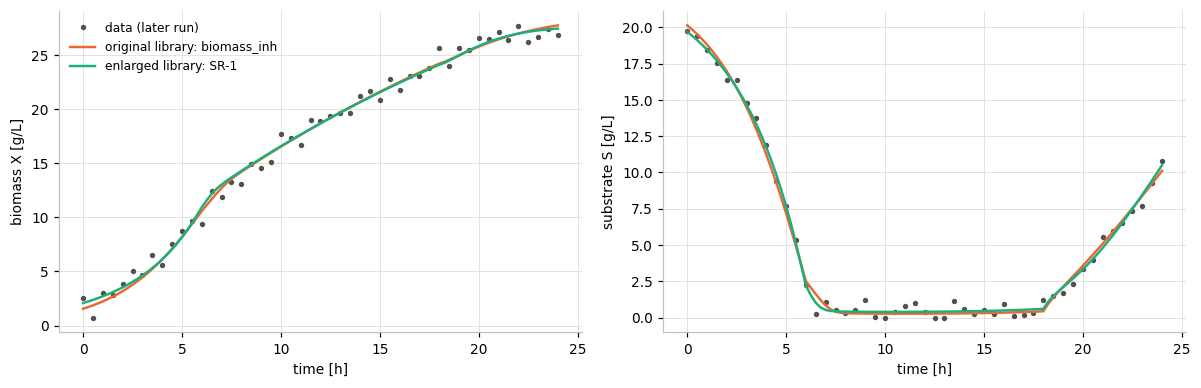

In [14]:
best_base = later_base.BIC.idxmin()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
fits = [(f"original library: {best_base}", C_MECH, simulate(LIBRARY[best_base], later_base.theta[best_base], T_DENSE,
                                                            later_base.x0[best_base], later_runs))]
if accepted:
    best_new = later_new.BIC.idxmin()
    fits.append((f"enlarged library: {best_new}", C_SR, simulate(LIBRARY_PLUS[best_new], later_new.theta[best_new],
                                                                  T_DENSE, later_new.x0[best_new], later_runs)))
for j, (ax, lab) in enumerate(zip(axes, ["biomass X [g/L]", "substrate S [g/L]"])):
    ax.plot(t_obs, later_runs[0]["Y"][:, j], "o", color=C_DATA, ms=2.5, label="data (later run)")
    for label, color, y in fits:
        ax.plot(T_DENSE, y[:, j], color=color, lw=1.6, label=label)
    ax.set(xlabel="time [h]", ylabel=lab)
axes[0].legend()
fig.tight_layout()

---
## Takeaways

**Step 1 — three runs break the confounding**
* **Library selection is correct in all 11 library experiments with three runs, against 7 of 11 on run a
  alone.** The four single-run misses were the confounded cases: Monod and Monod+$k_d$ read as Contois, Haldane
  as Contois, and Haldane+$k_d$ as Aiba. With three runs every one is selected with weight ≥ 0.86, except
  Tessier (0.54, with Aiba and Monod shortlisted: the three differ only at low substrate).
* **Every best library fit is within the noise** (χ² 223–310 for 294 data points), except the hidden
  experiment (χ² 2971). In part 2, with one run, the hidden law went unnoticed (χ² 106 for 98 points);
  with three runs a χ² test alone flags it.
* **The joint Neural ODE is the weak link.** It reaches the noise floor (loss ≈ 1e-3) for Monod,
  Monod+$k_d$, Tessier and both biomass-inhibition experiments, but stays at 2–6e-3 for Contois,
  Contois+$k_d$, Moser, Haldane, Aiba and the hidden law, and at 2.2e-2 for Haldane+$k_d$. Selection still
  works because it is decided by refining against the data, not by the learned rates.

**Step 2 — the exponential term reaches non-rational laws**
* **Aiba is recovered exactly:** $0.577\,S e^{-S/30.5}/(1 + 0.972\,S)$, that is $\mu_{max} = 0.59$,
  $K_S = 1.03$, $K_I = 30.5$ (true 0.6, 1, 30). It ties with the library's Aiba (ΔBIC −0.0).
* **No false discoveries.** On the 11 library experiments, the best symbolic-regression law ties with
  (Contois and Aiba rediscovered) or loses to the best library mechanism (ΔBIC up to +105 for Moser, which
  the dictionary cannot express).
* **Tessier is not singled out.** The best law found is Monod-like (ΔBIC +2.7): Tessier, Monod and Aiba
  differ only at low substrate, which the data barely sample.

**Escalation — when the library fails, screen against the data**
* On the hidden experiment, the shortlist built from the learned rates (2 per size) contains only an
  approximate law (χ² 440, outside the noise band). The learned rates are 20–30 % off in runs a and b, so the
  true term set ranks only 16th when matched to them.
* Screening all 67 valid laws against the data (4 min) finds the **true term set** $\{S, SX, \mu, \mu S^2\}$
  with χ² 258, inside the noise band, and constants close to the truth:
  $\mu = 0.614\,S(1 - X/30.0)/(1.07 + S + S^2/19.0)$, against $0.6\,S(1 - X/30)/(1 + S + S^2/20)$.
* The screening must refine the initial states too: held at their estimates from the first noisy samples
  (run c's biomass at 0.19 instead of 0.5 g/L), even the true law reaches only χ² ≈ 4400.

**Step 3 — closing the loop**
* **Only an adequate law is accepted.** The exact hidden law becomes SR-1 (ΔBIC −2707, χ² 258). The
  approximate law found before escalation (χ² 440) would have failed the noise check.
* **The enlarged library recognises the organism in a later run.** On one new run under new conditions, the
  original library picks biomass inhibition (weight 0.91); the enlarged library picks SR-1 (0.95, χ² 60 vs 71
  for 98 points). The two fits look alike because the new run never reaches high substrate, where the
  inhibition term matters; BIC still prefers SR-1.
* **The new entry steals nothing.** Refined on the 11 library experiments, SR-1 never gets more than 0.03
  of the weight, and every selection is unchanged.

**Caveats**
* One noise realisation per run, and one hidden law; these results were not repeated over noise draws.
* Escalation fires only when *no* library mechanism fits within the noise. A law missing from the library
  but closely approximated by a library mechanism would pass unnoticed.
* The joint Neural ODE does not reach the noise floor on half the experiments. Better-trained rates would
  make the cheap shortlist reliable and escalation rarer.